---
# <div style="text-align: center"> Introduction </div>
---

Along these tutorials, we will see how <span style="color:blue">**SCOPE**</span> interacts with the different parts of the code to handle the execution of computational workflows. 

These are the topics covered in each tutorial:
1) The **System** class and its sources: the **Specie**, **Cell** and **Atom** classes  
2) The Computational workflow: **Branch**, **Workflow**, **Job**, and **Computation** classes  
3) The **State** class  
4) The **Data**, **Collection** and **VNM** classes
5) The **Input_data** class, and **scope input files**
6) Running <span style="color:blue">**SCOPE**</span> - Part 1: File Structure
7) Running <span style="color:blue">**SCOPE**</span> - Part 2: Execution 
8) Running <span style="color:blue">**SCOPE**</span> - Part 3: Detailed Actions

In this tutorial, we discuss the specific Classes introduced in the **Azo** add-on of **SCOPE**. It is highly recommended to follow Tutorial 1 of the **core** package first.  
This tutorial is structured in 3 parts:

1) System and State Subclasses: **System_azo**, **State_azo**
2) Analysis of Thermal and Optical Properties: **PSS** and **Lamp** classes
3) Creation of new Azo systems

---
# <div style="text-align: center"> Azo Tutorial 1: Azo Add-on </div>
---

Azobenzene photoswitches can reversibly interconvert between **trans (E)** and **cis (Z)** isomers.

- **Trans (E)** is usually the thermodynamically more stable form. 
- **Cis (Z)** is typically less stable.

Light changes the population between these states because each isomer absorbs light differently:
- In the dark, the **trans** isomer is more stable. 
- Irradiation at one wavelength enriches **trans -> cis** (photoisomerization).
- Irradiation at another wavelength can drive the **cis -> trans** (back-isomerization).
- Once in **cis**, and without further irradiating, the system gradually reverts to **trans** (thermal relaxation). 

Mechanistically, thermal and phoo-induced isomerization can proceed through rotation or inversion around the azo unit (N=N). 
- Rotation can be characterized by the CNNC dihedral angle around the azo. 
- Inversion is characterized by the CNN angles

The energy profiles of these relaxation pathways dictate the thermal stability of the **cis** isomer. 
To characterize them using Transition State Theory (TST), one needs to find the minima and the transition states (TS) for each pathway. 

To make matters worse, there is a "triplet" channel, in which the **cis** isomer reverts to **trans** through a rotation-like pathway in which a triplet minimum is explored rather than the rotation TS.
This channel involves two inter-system crossing (ISC) steps: S-to-T, T-to-S. It is the energy of those crossing points (and not that of the triplet minimum) what matters in the context of TST.
Also, each ISC step is associated with a probability of hopping, so the actual TST theory needs to be modified, as we will discuss later.

In any case, here we grouped the TS in three types: 
- "**Inversion**": Referring to the inversion pathway in the **singlet** PES
- "**Rotation**":  Referring to the Rotation pathway in the **singlet** PES
- "**Triplet**":   Referring to the Rotation pathway in the **triplet** PES



## Part 1. System and State subclasses 

*Recap from Tutorial 1...*

> *A **System** is a collection of chemical entities sharing common properties, typically their chemical composition. 
Its main purpose is to store paths for later use in SCOPE, as well as its **sources***.

Here, we introduce the **System_azo** sub-class, tailored for azo-based molecules. 

In [1]:
import os
import numpy as np
import scope
import scope_azo

As we did in Tutorial 1, we start by loading an existing system, called "test":

In [2]:
## Path of the data folder. It should be "os.path.abspath('../')+'/Data/Azo/1-Tutorial_1/"
data_folder = os.path.abspath('../')+'/Data/Azo/1-Tutorial_1/'

## Loads the System object from a binary file, provided in the tutorial folder
sys = scope.load_binary(f"{data_folder}/Systems/test/test.npy")

In [3]:
## As usual, the Class has a __repr__ method to visualize key information 
print(sys)

-------------------------------------
   >>> SCOPE System_azo Object >>>   
-------------------------------------
 Name                  = test
 Dihedral Indices:     = [1, 0, 7, 8, 9, 10]
 Version               = 1.0
 Type                  = system
 Subtype               = system_azo
 Source Path           = /home/svela/SCOPE/Tutorial_azo/Sources/test/
 System File Path      = /home/svela/SCOPE/Tutorial_azo/Systems/test/
 System File Name      = /home/svela/SCOPE/Tutorial_azo/Systems/test/test.npy
 Computations Path     = /home/svela/SCOPE/Tutorial_azo/Computations/test/

 Num Sources           = 10
     idx: type, name, formula               
     0: specie, trans, H8-C12-N2-Cl2 
     1: specie, cis, H8-C12-N2-Cl2 
     2: specie, tsrot_a_s, H8-C12-N2-Cl2 
     3: specie, tsrot_a_t, H8-C12-N2-Cl2 
     4: specie, tsrot_b_s, H8-C12-N2-Cl2 
     5: specie, tsrot_b_t, H8-C12-N2-Cl2 
     6: specie, tsinv_l_a, H8-C12-N2-Cl2 
     7: specie, tsinv_l_b, H8-C12-N2-Cl2 
     8: specie, tsinv

In [4]:
## Notice that it follows the same structure as the core System class.
## Thus, you can use any of the functions defined therein.
sys.set_main_path(data_folder)  ## This is necessary to set the correct path for the data_folder, now that it is in your computer

# Notably, there is one additional attribute that is shown when printing the object: the Dihedral indices
sys.dihedral_indices

[1, 0, 7, 8, 9, 10]

### Trans vs. Cis

In [5]:
## These dihedral indices indicate the atoms involved in the Azo rotation. Lets visualize-them in the "trans" isomer:
found, trans = sys.find_source("trans")
print(found)
trans.view(show_indices=True)

True


In [6]:
## This is an azobenzene molecule with two clorine atoms in ortho position, it has two phenyl groups attached to an azo moiety (N=N). 
# Atoms 7 and 8 are the azo itself. 
# Atoms 0 and 9 are its 1st-nearest neighbours. That is, the ring atoms. 
# Atoms 1 and 10 are one of the two possible 2nd-nearest neighbours of the Azo moiety.

## Alltogether, these 6 atoms control the main geometrical features of azobenzene during its photo-isomerization (see introduction, and literature for further details).
## These are important when generating the standard Sources of the System_azo Class, as we will see in Part 3 of this tutorial

In [7]:
## As usual, we can select its sources for inspection. Here, we select its cis isomer: 
found, cis = sys.find_source("cis")
print(found)

## and visualize it:
cis.view(show_indices=True)

True


In [8]:
## Notice that the azo dihedral CNNC has changed.
## To get the actual value, you can use the geometry functions implemented in SCOPE:
P1, P2, P3, P4 = cis.coord[cis.dihedral_indices[1:5]]      ## Store the coordinates of the 4 atoms involved in the CNNC dihedral
radians = scope.geometry.get_dihedral(P1, P2, P3, P4)      ## Computes the dihedral angle in radians
degrees = np.degrees(radians)                              ## Converts to degree
print("CNNC cis:", degrees)

## As we will see later, this is not the optimum structure of the cis isomer, but just its 'initial' structure.

CNNC cis: 40.00000007148674


In [9]:
## If we evaluate the dihedral in the trans isomer...
P1, P2, P3, P4 = trans.coord[trans.dihedral_indices[1:5]]  ## Store the coordinates of the 4 atoms involved in the CNNC dihedral
radians = scope.geometry.get_dihedral(P1, P2, P3, P4)      ## Computes the dihedral angle in radians
degrees = np.degrees(radians)                              ## Converts to degree
print("CNNC trans:", degrees)

## In the trans isomer, the value should approach 180º
## Because of the bulky Cl atoms, the initial structure (generated by open-babel, see azo_functions.get_3D) slightly deviates from planarity

CNNC trans: 176.13097260926006


### Transition States

Eight (potential) TS structures can be generated automatically within SCOPE.

In [10]:
## Here you can find three representative transition states, one for each pathway discussed in the introduction:
found, ts_inv_l_a = sys.find_source("tsinv_l_a")
found, ts_rot_a_s = sys.find_source("tsrot_a_s")
found, ts_rot_a_t = sys.find_source("tsrot_a_t")

## You can uncomment below to visualize them
#ts_inv_l_a.view(show_indices=True)
#ts_rot_a_s.view(show_indices=True)
#ts_rot_a_t.view(show_indices=True)

In [11]:
## A summary of geometry features is available in the Molecule_azo class: 
ts_inv_l_a.get_geometry_summary()

## Notice the Left Inv. Angle (CNN), corresponding to an Inversion-like structure.

-------------------------------------------------
 Main Geometry Features of the Azo group:        
-------------------------------------------------
 NN distance (dNN):         1.2446 
 Left Inv. Angle (CNN):     179.9 
 Right Inv. Angle (NNC):    114.9822 
 Main Dihedral (CNNC):      176.131 
 Adj Dihedral Left (CCNN):  0.0 
 Adj Dihedral Right (NNCC): -54.5355 



In [12]:
## This is in contrast with rotation-like structures, which feature a CNNC close to 90º, and CNN and NNC angles close to 113º. 
ts_rot_a_s.get_geometry_summary()


-------------------------------------------------
 Main Geometry Features of the Azo group:        
-------------------------------------------------
 NN distance (dNN):         1.2446 
 Left Inv. Angle (CNN):     113.8583 
 Right Inv. Angle (NNC):    114.9822 
 Main Dihedral (CNNC):      90.0 
 Adj Dihedral Left (CCNN):  6.7616 
 Adj Dihedral Right (NNCC): -0.0 



In [13]:
## These features are also printed in the main __repr__ method of the Molecule_azo class:
ts_rot_a_s

---------- SCOPE Molecule_azo Object ------------
 Version               = 1.0
 Type                  = specie
 Sub-Type              = molecule_azo
 Name                  = tsrot_a_s
 Number of Atoms       = 24
 Formula               = H8-C12-N2-Cl2
 Charge                = 0
 Spin (alpha - beta)   = 0
 Number of Parents     = 0
 Has Adjacency Matrix  = NO 
 Has Bonds             = NO
-------------------------------------------------
 Main Geometry Features of the Azo group:        
-------------------------------------------------
 NN distance (dNN):         1.2446 
 Left Inv. Angle (CNN):     113.8583 
 Right Inv. Angle (NNC):    114.9822 
 Main Dihedral (CNNC):      90.0 
 Adj Dihedral Left (CCNN):  6.7616 
 Adj Dihedral Right (NNCC): -0.0 

In [14]:
## Notice that tsrot_a_s is defined as a singlet (spin = 0). The same holds for ts_inv_l_a
print("Spin:", ts_rot_a_s.spin)

Spin: 0


In [15]:
## Instead, the 'triplet' TSs are defined as spin = 2 (as expected)
print(ts_rot_a_t)

---------- SCOPE Molecule_azo Object ------------
 Version               = 1.0
 Type                  = specie
 Sub-Type              = molecule_azo
 Name                  = tsrot_a_t
 Number of Atoms       = 24
 Formula               = H8-C12-N2-Cl2
 Charge                = 0
 Spin (alpha - beta)   = 2
 Number of Parents     = 0
 Has Adjacency Matrix  = NO 
 Has Bonds             = NO
-------------------------------------------------
 Main Geometry Features of the Azo group:        
-------------------------------------------------
 NN distance (dNN):         1.2446 
 Left Inv. Angle (CNN):     113.8583 
 Right Inv. Angle (NNC):    114.9822 
 Main Dihedral (CNNC):      90.0 
 Adj Dihedral Left (CCNN):  6.7616 
 Adj Dihedral Right (NNCC): -0.0 



## Part 2: Thermal Properties

Here, we discuss the 

```bash
scope run -n scope_env_tutos_azo.npy -s test -i 1-opt_min.scope  2-opt_ts.scope  3-freq_min.scope  4-freq_ts.scope  5-td_min.scope -v -e
```

### Trans vs. Cis stability

In [16]:
## From the results, one can easily retrieve the Cis - Trans energy difference at a given temperature
sys.get_thermal_stability(target_state='opt', temp=298.15, debug=0) 

dG_cis-trans:   3.55011349 kcal/mol

### Finding the Minimum Energy Transition State (METS)

In [17]:
# To find the METS, the function get_mets() goes through all sources with the target state (target_state). 
# - For sources defined in a singlet state, it verifies that it is a TS (one sizeable negative frequency)
# - For sources defined as a triplet, it verifies that it is a minimum (all frequencies are positive, or almost). 
#   Also, it applies an energy penalty to Gtot, to compensate for the ISC processes. 
#   This penalty is applied as dE = - RT ln(p_sh), where p_sh is the probability of surface hopping.
#   Here, p_sh is set to 0.0002, so dE amounts 5 kcal/mol at 298.15 K.
#   This value is a parameter, and can be modified by the user. 
    
## Finally, it selects and returns the source with a lowest Gtot at the requested temperature (temp). That is, the METS
mets = sys.get_mets(temp=298.15, target_state='opt')

In [18]:
## In this case, the METS is a structure associated with a rotation in the triplet surface
print(mets)

---------- SCOPE Molecule_azo Object ------------
 Version               = 1.0
 Type                  = specie
 Sub-Type              = molecule_azo
 Name                  = tsrot_a_t
 Number of Atoms       = 24
 Formula               = H8-C12-N2-Cl2
 Charge                = 0
 Spin (alpha - beta)   = 2
 Number of Parents     = 0
 Has Adjacency Matrix  = NO 
 Has Bonds             = NO
-------------------------------------------------
 Main Geometry Features of the Azo group:        
-------------------------------------------------
 NN distance (dNN):         1.2446 
 Left Inv. Angle (CNN):     113.8583 
 Right Inv. Angle (NNC):    114.9822 
 Main Dihedral (CNNC):      90.0 
 Adj Dihedral Left (CCNN):  6.7616 
 Adj Dihedral Right (NNCC): -0.0 



In [19]:
## The Geometry Features shown above refer to the SOURCE in its INITIAL state. To see those values in the computed target_state (opt), we need to load it:
found, mets_opt_state = mets.find_state("opt")
print(mets_opt_state)

---------- SCOPE State_azo Object ------------
 Name                  = opt
 Source Name           = tsrot_a_t
 Source Type           = specie
 Labels                = C...
 Coord                 = [-0.173125, -1.044504, -0.658308]...
 Number of Units (Z)   = 1

 Has VNMs              = YES
 Is Minimum            = True
 Is a Transition State = False
 First Freq (cm-1)     = 19.8729

 # Molecules:          = 1
 With Formulae:                               
    0: H8-C12-N2-Cl2 
-------------------------------------------------
 Main Geometry Features of the Azo group:        
-------------------------------------------------
 NN distance (dNN):         1.2661 
 Left Inv. Angle (CNN):     127.971 
 Right Inv. Angle (NNC):    128.0156 
 Main Dihedral (CNNC):      110.9285 
 Adj Dihedral Left (CCNN):  -11.9885 
 Adj Dihedral Right (NNCC): -11.8401 



#### Gtot vs. Gtot_eff

In [20]:
## Beyond geometry, this state is associated with a Gtot value at 298.15K. 
## This value includes vibrational and electronic enthalpy and entropy terms, as discussed in Tutorial 4.
## This are automatically computed during sys.get_mets(), and stored appropriately as State results for each Isomer (cis, trans, ts...)
Gtot_eff = mets_opt_state.results['Gtot_eff']

## Technically, Gtot is an instance of the Collection-class:
print(Gtot_eff)

---------------------------------------------------
   COLLECTION OF DATA   = Gtot_eff                
---------------------------------------------------
 Variable              = temperature
 Num of Entries        = 1
 First                 = -1490.8317518596448
 Last                  = -1490.8317518596448
 Units                 = au
 Function              = state_azo.get_gtot_eff()



In [21]:
## Collections store multiple values associated with the same variable (here, Gtot) but under different circumstances (e.g. temperature). 
## To find the Gtot value at a specific temperature, you can do:
print(Gtot_eff.find_value_with_property('temperature', 298.15))

Gtot_eff: -1490.83175186 au (at temperature=298.15)


In [22]:
# The name 'Gtot_eff' means that any energy penalty has already been considered. 
# In this case, since the METS is a triplet, Gtot_eff differs from the 'original' (i.e. without penalty) Gtot
Gtot = mets_opt_state.results['Gtot'].find_value_with_property('temperature', 298.15)
print(Gtot)
## Notice the slight difference in energy...

Gtot: -1490.83979360 au (at temperature=298.15)


In [23]:
## This difference in energy corresponds to the energy penalty associated with the triplet states
diff = Gtot - Gtot_eff.find_value_with_property('temperature', 298.15)
diff.convert_to_units('kcal')

## In singlet states, Gtot and Gtot_eff should be equal

sum_Gtot:  -5.04627077 kcal

### Halflife time

In [24]:
## Overall, with the METS energy, and that of the Trans isomer, one can get obtain the rate constant (k) and the halflife time (t05) of each isomer:
sys.get_cis_halflife_time(temp=298.15, debug=0)

cis_halflife_time: 264.61534987 s (at temperature=298.15)

In [25]:
# The halflife time is stored as a result for this system:
print(sys.results['cis_halflife_time'])

# Together with the thermal relaxation rate
print(sys.results['rate_thermal_cis2trans'])

# and the dG=(G_TS - G_cis)
print(sys.results['dG_from_cis'])

cis_halflife_time: 264.61534987 s (at temperature=298.15)
rate_thermal_cis2trans:   0.00261945 s (at temperature=298.15)
dG_from_cis:  20.97520978 kcal/mol (at temperature=298.15)


In [26]:
## This is also possible for the trans isomer: 
sys.get_trans_halflife_time(temp=298.15, debug=0) 

trans_halflife_time: 105897.54166269 s (at temperature=298.15)

## Part 3. Optical Properties

In [27]:
# Apart from the cis-trans thermal stability, one of the key properties of Azo complexes is their light-absorption profile.
# For the test compound, the absorption spectrum is simulated using the excited states data obtained from TD-DFT.
# Here, this data is stored in the 'opt' state. 
found, trans_source = sys.find_source('trans')
found, trans_state  = trans_source.find_state('opt')
print(trans_state)

---------- SCOPE State_azo Object ------------
 Name                  = opt
 Source Name           = trans
 Source Type           = specie
 Labels                = C...
 Coord                 = [-0.031101, -0.036525, 0.03185]...
 Number of Units (Z)   = 1

 Has VNMs              = YES
 Is Minimum            = True
 Is a Transition State = False
 First Freq (cm-1)     = 17.3076

 Has Excited States    = YES
 # Molecules:          = 1
 With Formulae:                               
    0: H8-C12-N2-Cl2 
-------------------------------------------------
 Main Geometry Features of the Azo group:        
-------------------------------------------------
 NN distance (dNN):         1.2372 
 Left Inv. Angle (CNN):     115.3575 
 Right Inv. Angle (NNC):    115.3682 
 Main Dihedral (CNNC):      179.9971 
 Adj Dihedral Left (CCNN):  42.0511 
 Adj Dihedral Right (NNCC): -42.1224 



In [28]:
# The excited states are stored as an attribute:
trans_state.exc_states

[-----------------------------
    Electronic Excited State  
 -----------------------------
  Index                  = 1
  Energy (eV)            = 2.6097 eV
  Wavelength (nm)        = 475.08 nm
  Oscillator Strength    = 0.0,
 -----------------------------
    Electronic Excited State  
 -----------------------------
  Index                  = 2
  Energy (eV)            = 4.3288 eV
  Wavelength (nm)        = 286.42 nm
  Oscillator Strength    = 0.3999,
 -----------------------------
    Electronic Excited State  
 -----------------------------
  Index                  = 3
  Energy (eV)            = 4.6914 eV
  Wavelength (nm)        = 264.28 nm
  Oscillator Strength    = 0.0,
 -----------------------------
    Electronic Excited State  
 -----------------------------
  Index                  = 4
  Energy (eV)            = 4.8376 eV
  Wavelength (nm)        = 256.29 nm
  Oscillator Strength    = 0.1448,
 -----------------------------
    Electronic Excited State  
 -------------------

### Absorption Spectrum

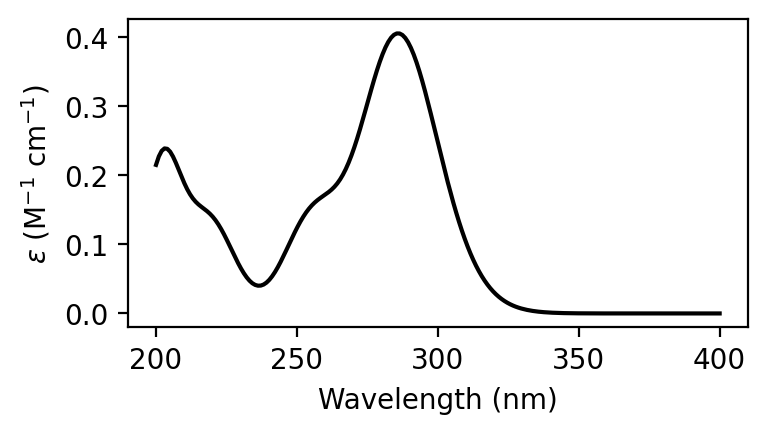

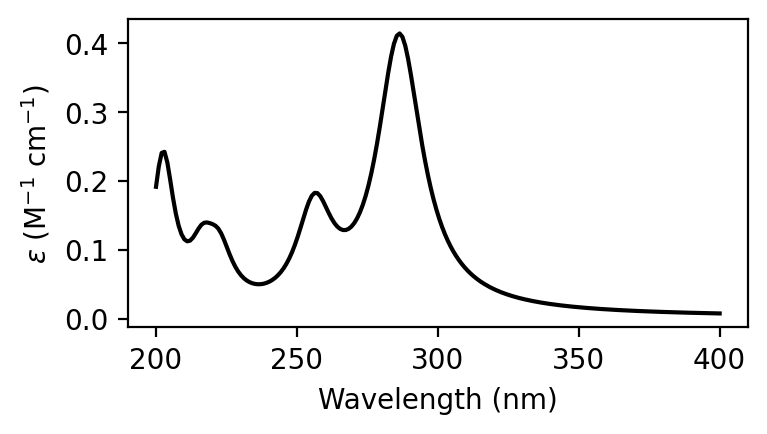

In [29]:
# Alltogether, they generate the absorption spectrum
trans_state.plot_abs_spectrum(lmin=200, lmax=400, function='gaussian', sigma=0.2)

# Alternatively, if you prefer the spectrum as x, y arrays, you can run: 
# x, y = trans_state.get_abs_spectrum(lmin=200, lmax=400, function='gaussian', sigma=0.2)

# In both cases, we selected gaussian functions with sigma=0.2 for the convolution. 
# Lorentzian and Laplacian functions can be used instead, as well as other sigma values
trans_state.plot_abs_spectrum(lmin=200, lmax=400, function='lorentzian', sigma='auto')

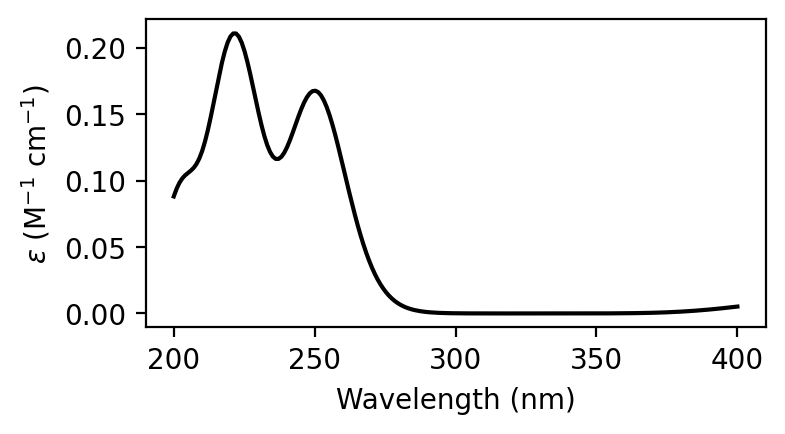

In [30]:
# Of course, the same holds for the 'cis' isomer:
found, cis_source = sys.find_source('cis')
found, cis_state  = cis_source.find_state('opt')
cis_state.plot_abs_spectrum(lmin=200, lmax=400, function='gaussian', sigma=0.2)

### The Photo-Stationary State (PSS)

Under light irradiation, Azo molecules reach a stationary state, in which both the trans(E) and cis(Z) isomers are populated.
The actual population depends on the rates of thermal relaxation, and photo-induced isomerization. This is called, the **photostationary state (PSS)** ($\chi _E $).

$$
\chi _E = \frac{k_{th}^{ZE} + k_{ph}^{ZE}} {k_{ph}^{EZ} + k_{ph}^{ZE} + k_{th}^{EZ} + k_{th}^{ZE}}
$$

where:

- $k_{th}^{ij}$ are the thermal rates from isomer *i* to *j*
- $k_{ph}^{ij}$ are the photo-isomerization equivalents, defined as:

$k_{ph}^{ij} = \Phi_{ij}\quad*\quad\int(\sigma_Z (\lambda) · \phi · \lambda) d\lambda$ 

where: 

$\Phi_{ij}$ is the Quantum Yield, defined as the ratio of absorbed photons that lead to photoisomerization

WIP WIP WIP WIP

#### The 'Lamp' Class

In [31]:
# The properties of the light source are provided to the PSS as a Lamp-Class object.
# Lamps store information about the available wavelengths, and associated FWHM and Power values.
# If you don't have such information, you can use a "default" Lamp that we provide within SCOPE.
# Any Lamp can be tuned at will by the user, and new Lamps can also be added as simple JSON files. 
my_lamp = scope_azo.azo_classes.Lamp("default")
print(my_lamp)

--------- Scope Lamp Object -----------
 Name             = default
 Wavelengths      = [250 280 310 340 370 400 430 460 490 520 550 580] nm
 FWHM             = [20. 20. 20. 20. 20. 20. 20. 20. 20. 20. 20. 20.] nm
 Power            = [50. 50. 50. 50. 50. 50. 50. 50. 50. 50. 50. 50.] mW
 Power Intensity  = 1.0
---------------------------------------



In [32]:
# Basically, this Lamp provides 12 excitation wavelentghs defined as:
# - gaussians of FWHM=20 nm
# - with 50 mW of power when used at 100% (Power Intensity=1.0). Can be changed with my_lamp.set_power_intensity()

In [33]:
# For the moment, only one real-world device has been included, the CoolLED pE-4000:
my_lamp = scope_azo.azo_classes.Lamp("coolled")
print(my_lamp) 

--------- Scope Lamp Object -----------
 Name             = coolled
 Wavelengths      = [365 385 405 435 460 470 500 525 550 595 635 660 740 770] nm
 FWHM             = [12.54 11.38 16.08 13.02 17.61 23.26 24.72 28.32 82.79 14.61 16.72 21.42
 41.12 27.75] nm
 Power            = [ 15.12  59.39 188.32 138.75 240.19 192.29  59.26  39.   166.74  32.52
 123.88 159.01  36.62  15.61] mW
 Power Intensity  = 1.0
---------------------------------------



In [34]:
# Finally, absence of irradiation can be simulated with the "dark" Lamp:
my_lamp = scope_azo.azo_classes.Lamp("dark")
print(my_lamp) 

--------- Scope Lamp Object -----------
 Name             = dark
 Wavelengths      = [365] nm
 FWHM             = [1.] nm
 Power            = [0.] mW
 Power Intensity  = 0.0
---------------------------------------



In [35]:
# To compute the PSS, one just needs to use the get_PSS() function as:
my_pss = sys.get_PSS(lamp_name='default', target_state='opt', temp=298.15, lmin=200, lmax=600)

# This function has several options and defaults, do not forget to read the docs if necessary:
#help(sys.get_PSS)

# In summary, the function takes/computes all relevant data from the stored sources (trans, cis), and creates a PSS-class instance:
print(my_pss)

# This class stores relevant data to compute the PSS at any given wavelength, such as the thermal rates.

------------------------------
   >>> SCOPE PSS Object >>>   
------------------------------
 System             = test
 Lamp Name          = default
 Lamp Wavelengths   = [250 280 310 340 370 400 430 460 490 520 550 580] (nm)
 Lamp FWHM          = [20. 20. 20. 20. 20. 20. 20. 20. 20. 20. 20. 20.] (nm)
 Lamp Powers        = [50. 50. 50. 50. 50. 50. 50. 50. 50. 50. 50. 50.] (mW)
 Illuminated Area   = 78.539816 (mm2)
 Rate Thermal E->Z  = 6.545451e-06 (s)
 Rate Thermal Z->E  = 2.619452e-03 (s)
 Num of Results     = 12




In [42]:
# Wavelength-dependent results are stored as a dictionary, with wavelengths as keys:
res = my_pss.pss_results[250]

print(res['wavelength'])                ## Wavelength of irradiation
print(res['pss_trans_ratio'])           ## Ratio of Trans Isomer in the PSS
print(res['rate_photo_trans2cis'])      ## Photoisomerization Rate for E-->Z at this wavelength 
print(res['rate_photo_cis2trans'])      ## Photoisomerization Rate for Z-->E at this wavelength   
print(res['rate_thermal_trans2cis'])    ## Thermal Reaction Rate for E-->Z (independent of wavelength) 
print(res['rate_thermal_cis2trans'])    ## Thermal Reaction Rate for Z-->E (independent of wavelength) 
print(res['QY_trans2cis'])              ## Quantum Yield for E-->Z photoisomerization at this wavelength  
print(res['QY_cis2trans'])              ## Quantum Yield for Z-->E photoisomerization at this wavelength


250
0.6616350705797629
0.0851876608382521
0.16396836436209503
6.5454510999680045e-06
0.0026194518983660817
0.3
0.5


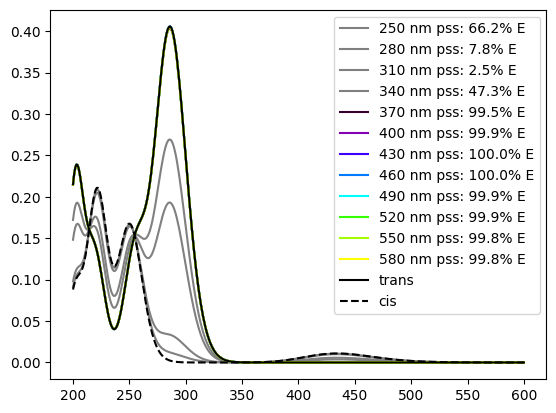

In [ ]:
# Results can be plotted with:
my_pss.plot_spectra()

In [ ]:
# Above, we can see that we only obtain a mixture of E and Z isomers under light between 250-340 nm. 
# For all other cases, only the trans state is present

# These are, unfortunately, boring results from the chemistry point of view. 

## Part 4. Creating new Azo-based Systems

Throughout the previous tutorials, <span style="color:blue">**SCOPE**</span> has interacted with different parts of the code to handle the execution of computational workflows. 

In the first part of this tutorial, we will create a **SYSTEM_AZO**, from its SMILES string, and learn about the creation of its main isomers (cis and trans), and initial Transition State structures.  
In the second part, we will create a new system from scratch, and feed it with **sources**. 

In [2]:
# First, let's define a SMILES string. It is important to be careful when 
#   constructing your SMILES: it must follow the pattern below to correctly detect
#   atom indices near the Azo group, enabling rotation and inversion of both rings.

#   IMPORTANT: SMILES strings MUST adhere to the following structure:
#                    'C1(...C1)/N=N/ring2' 
#                              or
#                    'C1(...C1)/N=N\\ring2' 


# We will select azobenzene for its simplicity. Let's store the SMILES string and its name.
 
smiles = 'c1(ccccc1)/N=N/c2ccccc2'
name = 'Azobenzene'


### The SYSTEM_AZO class: Where it all begins 

In [3]:
# We will create our system as a System_azo object providing its name and the smiles. 
azo_sys = scope_azo.System_azo(name, smiles)

In [4]:
# The SYSTEM_AZO class is a subtype of SYSTEM, as you can check:
print('Type:    ' ,azo_sys.type)
print('Subtype: ' ,azo_sys.subtype)

Type:     system
Subtype:  system_azo


In [5]:
# System_azo now possesses all the features of Systems. 
# You can confirm this by checking its _repr_ method:
azo_sys

# Note that a new attribute, 'dihedral_indices' is shown. 
# These will be relevant later.

------------- SCOPE System_azo Object -------
 Name                  = Azobenzene
 Version               = 1.0
 Type                  = system
 Subtype               = system_azo
 Dihedral Indices:     = [1, 0, 6, 7, 8, 9]
---------------------------------------------


### Working with System_azo Objects

Given a `system_azo` object, it's possible to obtain relevant structures such as **cis** and **trans** isomers. These functions from the `System_azo` class allow the creation of cis/trans isomers **and their transition state geometries**:

* **`System_azo.create_trans()`**
    * Creates **trans** structures.
    * It uses the SMILES string stored in the System to generate 3D coordinates.

* **`System_azo.create_cis(target_deg=40.)`**
    * Creates **cis** structures from the **trans** isomer.
    * *Note:* If the trans isomer has not been created before, it returns an error.
    * If everything works, it adds the cis isomer as a `Molecule_azo` object as source of the system.
    * The `target_deg` parameter allows you to choose the torsion of the dihedral angle of the Azo group (CN=NC). Please, insert your target angle in degrees.

* **`System_azo.create_ts(ts_list=['TSrot', 'TSinv_l', 'TSinv_r', 'triplet'])`**
    * The `ts_list` list parameter allows you to choose between which TS structures you want to create:
        * **`TSrot`**: Rotation of the azo group. Dihedral angles are set up as +90º (`TSrot_A`) and -90º (`TSrot_B`) in singlet state.
        * **`TSinv_l`**: Inversion of the left ring. The angle between CN=N atoms in the CN=NC azo group is set up as 180º.
        * **`TSinv_r`**: Inversion of the right ring. The angle between N=NC atoms in the CN=NC azo group is set up as 180º.
        * **`triplet`**: If this tag is selected, the `TSrot` are also created in the triplet state, by setting its spin as 2.

> You can read the docstring of each function for more information.

In [6]:
# If we attempt to create the cis isomer without first creating the trans isomer, it will raise an error.
azo_sys.create_cis()

Exception: AZO.CREATE_CIS: [ERROR] Trans isomer not found. Create it first with self.create_trans()

In [7]:
# Let's create the trans isomer. Note that the 'overwrite' parameter defaults to False.
trans_iso = azo_sys.create_trans(overwrite=True)
print(trans_iso)

---------- SCOPE Molecule_azo Object ------------
 Version               = 1.0
 Type                  = specie
 Sub-Type              = molecule_azo
 Name                  = trans
 Number of Atoms       = 24
 Formula               = H10-C12-N2
 Charge                = 0
 Spin (alpha - beta)   = 0
 SMILES                = c1(ccccc1)/N=N/c2ccccc2
 Number of Parents     = 0
 Has Adjacency Matrix  = NO 
 Has Bonds             = NO
-------------------------------------------------



In [8]:
# Species can be visualize using the method .view()
trans_iso.view(show_indices=True)

#Note: If you are running this on a remote cluster, the visualizer may take a while to load.

In [9]:
# Now we can generate the cis isomer. This returns a Molecule_azo object, which is automatically 
# registered as a source in our azobenzene system.
cis_iso = azo_sys.create_cis()
print(cis_iso)

---------- SCOPE Molecule_azo Object ------------
 Version               = 1.0
 Type                  = specie
 Sub-Type              = molecule_azo
 Name                  = cis
 Number of Atoms       = 24
 Formula               = H10-C12-N2
 Charge                = 0
 Spin (alpha - beta)   = 0
 SMILES                = c1(ccccc1)/N=N\c2ccccc2
 Number of Parents     = 0
 Has Adjacency Matrix  = NO 
 Has Bonds             = NO
-------------------------------------------------



In [10]:
# Finally, we can generate the Transition State (TS) geometries. 
# These are returned as a list and automatically registered as sources in the System_azo.

ts_list = azo_sys.create_ts()
print([ts.name for ts in ts_list])

# Pay attention to the naming convention: 
# Since all TSs are generated, the singlet and triplet states are labeled 
# 'TSrot_A_S' and 'TSrot_A_T', respectively.

['tsrot_a_s', 'tsrot_a_t', 'tsrot_b_s', 'tsrot_b_t', 'tsinv_l', 'tsinv_r']


In [11]:
# One way to recover sources is by its index, look at the indices above. For the cis isomer, the index is 1. 

cis = azo_sys.sources[1]
print(cis)

# Moreover, as Molecule_azo is a subclass of the MOLECULE/SPECIE class, we can use its functions, 
#   providing a great implementation with SCOPE features.
cis.view(show_indices=True)

---------- SCOPE Molecule_azo Object ------------
 Version               = 1.0
 Type                  = specie
 Sub-Type              = molecule_azo
 Name                  = cis
 Number of Atoms       = 24
 Formula               = H10-C12-N2
 Charge                = 0
 Spin (alpha - beta)   = 0
 SMILES                = c1(ccccc1)/N=N\c2ccccc2
 Number of Parents     = 0
 Has Adjacency Matrix  = NO 
 Has Bonds             = NO
-------------------------------------------------



In [12]:
# We can recover the source using their names. For instance, we can look for the one called 'trans'...
trans = azo_sys.find_source('trans')[1]
print(trans)

---------- SCOPE Molecule_azo Object ------------
 Version               = 1.0
 Type                  = specie
 Sub-Type              = molecule_azo
 Name                  = trans
 Number of Atoms       = 24
 Formula               = H10-C12-N2
 Charge                = 0
 Spin (alpha - beta)   = 0
 SMILES                = c1(ccccc1)/N=N/c2ccccc2
 Number of Parents     = 0
 Has Adjacency Matrix  = YES
 Has Bonds             = NO
-------------------------------------------------



In [13]:
# ... or one of the rotation TS in the triplet state 'TSrot_A_T'. 
ts = azo_sys.find_source('TSrot_a_t')[1]
print(ts)

---------- SCOPE Molecule_azo Object ------------
 Version               = 1.0
 Type                  = specie
 Sub-Type              = molecule_azo
 Name                  = tsrot_a_t
 Number of Atoms       = 24
 Formula               = H10-C12-N2
 Charge                = 0
 Spin (alpha - beta)   = 2
 Number of Parents     = 0
 Has Adjacency Matrix  = NO 
 Has Bonds             = NO
-------------------------------------------------



In [14]:
# The 3D structure of the models is created with Openbabel, and is accessible through:
print(trans.labels)
print(trans.coord)

['C', 'C', 'C', 'C', 'C', 'C', 'N', 'N', 'C', 'C', 'C', 'C', 'C', 'C', 'H', 'H', 'H', 'H', 'H', 'H', 'H', 'H', 'H', 'H']
[[ 0.          0.          0.        ]
 [-0.51281336  1.30759191 -0.01964106]
 [-1.89451179  1.54886149 -0.01287176]
 [-2.79054639  0.48491126 -0.0356827 ]
 [-2.30684183 -0.820513   -0.04679195]
 [-0.92678473 -1.05609187 -0.02166651]
 [ 1.41048717 -0.16819286  0.08485943]
 [ 1.75056616 -1.37115871  0.13165836]
 [ 3.12815606 -1.57218314  0.36965153]
 [ 3.76079853 -2.64456496 -0.27758107]
 [ 5.08602564 -2.98826028  0.01472445]
 [ 5.81201493 -2.23890833  0.93462448]
 [ 5.20425284 -1.16482726  1.58394187]
 [ 3.86719973 -0.84465022  1.312251  ]
 [ 0.17005349  2.15269137 -0.02956064]
 [-2.26985447  2.56978884  0.01876031]
 [-3.8625511   0.66852757 -0.04428309]
 [-2.99892996 -1.65771281 -0.06143462]
 [-0.58140473 -2.0871111  -0.00947184]
 [ 3.2081124  -3.22976847 -1.0071315 ]
 [ 5.54380937 -3.84906914 -0.46783483]
 [ 6.84682129 -2.4945858   1.15225226]
 [ 5.76428278 -0.5887

In [15]:
# These Molecules_azo store labels and coordinates of the geometry stored in the 'initial' state.
import numpy as np

initial_state = trans.find_state('initial')[1]
print('Coordinates are equal: ', np.array_equal(initial_state.coord,trans.coord))

Coordinates are equal:  True


In [16]:
# Let's inspect the relevant atom indices for the trans isomer by accessing the 
# 'dihedral_indices' attribute:

print('Atom Indices for Dihedral: ', azo_sys.dihedral_indices)

# Recall that the atoms involved in the C-N=N-C rotation correspond to indices 0, 6, 7, and 8.
# These represent the four atoms extracted from the index list defining the torsion.

# The first and last elements of this list correspond to the anchor atoms of the 
# left and right rings, respectively.

# The variables 'atom0' and 'atom1' will be used to facilitate independent ring rotation.

atom0, atom1, atom2, atom3, atom4, atom5 = azo_sys.dihedral_indices

Atom Indices for Dihedral:  [1, 0, 6, 7, 8, 9]


In [23]:
# These indices allow us to analyze geometric parameters, such as the dihedral angle defined by the C-N=N-C ...
coord = trans.coord
dih_angle = np.degrees(scope.geometry.get_dihedral(coord[atom1], coord[atom2], coord[atom3], coord[atom4]))
print(f'{dih_angle:.2f} degrees')

173.14 degrees


In [24]:
# ... or the angle between CNN atoms. Here is the angle defined by the CN=N atoms. 
angle = np.degrees(scope.geometry.get_angle(coord[atom1] - coord[atom2], coord[atom2] - coord[atom3]))
print(f'{angle:.2f} degrees')

67.33 degrees


In [26]:
# Using the core SCOPE module, modifying dihedral angles is straightforward:

# (Caution: Rotations may lead to steric clashes. See the 'Advanced Users'
#  section at the end of this Notebook for details.)

rotated_coord = scope.geometry.set_dihedral(trans.labels, coord, 30, atom1, atom2, atom3, atom4)
new_molec     = scope_azo.Molecule_azo(trans.labels, rotated_coord)
new_molec.view(show_indices=True)

# Notice the steric clashes involving atoms 5, 13, 18, and 23. 
# Don't worry—we have a specific solution to resolve this.

In [ ]:
# The create_cis() method automatically resolves steric clashes when rotating 
# to a specific angle, defined by the 'target_deg' parameter.

# We recommend using this function for geometries prone to collisions (steric hindrance),
# as it automatically adjusts adjacent rings to achieve a valid, clash-free conformation.
azo_sys.create_cis(target_deg=30, overwrite=True).view()

> **Pro Tip:** We recommend using `create_cis()` for geometries prone to steric hindrance. It automatically adjusts adjacent rings to ensure a valid, clash-free conformation.

### Set Paths and calculations 

In [27]:
# Now, let's configure the directory paths. 
# You can use the interactive azo_sys.set_paths() method (ideal for terminal sessions) 
# or define them manually. Below, we demonstrate the explicit approach.
 
tutorial_folder = os.path.abspath('../')+'/Data/Azo/'
print(tutorial_folder)

# Defining paths explicitly:
azo_sys.set_main_path(f"{tutorial_folder}")
azo_sys

/Users/sergivela/Documents/SCOPE/Program/Scope_Tutorials/Data/Azo/


------------- SCOPE System_azo Object -------
 Name                  = Azobenzene
 Version               = 1.0
 Type                  = system
 Subtype               = system_azo
 Source Path           = /Users/sergivela/Documents/SCOPE/Program/Scope_Tutorials/Data/Azo/Sources/Azobenzene/
 System File Path      = /Users/sergivela/Documents/SCOPE/Program/Scope_Tutorials/Data/Azo/Systems/Azobenzene/
 System File Name      = /Users/sergivela/Documents/SCOPE/Program/Scope_Tutorials/Data/Azo/Systems/Azobenzene/Azobenzene.npy
 Computations Path     = /Users/sergivela/Documents/SCOPE/Program/Scope_Tutorials/Data/Azo/Computations/Azobenzene/

 Num Sources           = 8
     idx: type, name, formula               
     0: specie, trans, H10-C12-N2 
     1: specie, cis, H10-C12-N2 
     2: specie, tsrot_a_s, H10-C12-N2 
     3: specie, tsrot_a_t, H10-C12-N2 
     4: specie, tsrot_b_s, H10-C12-N2 
     5: specie, tsrot_b_t, H10-C12-N2 
     6: specie, tsinv_l, H10-C12-N2 
     7: specie, tsinv_r,

In [29]:
# The system can be saved to a .npy binary using 'load_binary()' function.
# As we have just assigned the system filepath, saving the binary becomes easy.

scope.save_binary(azo_sys, azo_sys.system_file)

## Part 2. Going further: Combining smiles. (WIP)

In [ ]:
# In computational studies, it is common to study multiple systems simultaneously.

# To speed up this, we allow you to construct systems by combining specific ring structures.
# You simply need to provide the SMILES for each ring (including substituents), adhering to 
# the pattern shown above:
#                           C1(...C1)/N=N/ring2 

# From now on, we will refer to these rings as 'fragments'.

# As an example, let's define two fragments for the left ring and one for the right.
# IMPORTANT: Each fragment MUST be a string stored within a list.

lefts   = ['C1=(C-C=C-C=C1)','C1=(CC=NC=C1)']
rights  = ['c2ccccc2']



In [ ]:
# The combine_smiles() function returns a list containing every combination of the fragments. 
# You can optionally provide a filename to save the output to a text file.

combine_smiles(lefts,rights)

# NO FUNCIONA ENCARA 

TypeError: combine_smiles() missing 1 required positional argument: 'subs'

In [ ]:
azoben_sys